In [47]:
import gymnasium as gym
import numpy as np 
import matplotlib.pyplot as plt
import random

# Problem 1 Code

## 1c

In [153]:
def fixed_policy(state):
    player_sum, dealer_card, usable_ace = state

    if player_sum >= 20:
        return 0
    
    else:
        return 1

In [167]:
def single_episode_prediction(env):
    episodes = []

    state, info = env.reset()
    complete = False

    while not complete:
        action = fixed_policy(state)

        next_state, reward, terminated, truncated, info = env.step(action)

        episodes.append((state, reward))

        state = next_state

        if terminated is True or truncated is True:
            complete = True
             
    return episodes


In [168]:
def first_visit_mc_prediciton(env, episodes, gama):
    V = {}
    N = {}

    for eps in range(episodes):
        episode = single_episode_prediction(env)

        states = []
        rewards = []

        for each in episode:
            states.append(each[0])
            rewards.append(each[1])

        G = 0

        for t in reversed(range(len(episode))):
            state = states[t]
            reward = rewards[t]

            G = reward + gama * G

            if state not in states[:t]:
                if state not in V:
                    V[state] = 0
                    N[state] = 0
                    
                N[state] += 1
                V[state] = V[state] + (1 / N[state]) * (G - V[state])

    return V, N


In [169]:

def heat_map_grid(V, usable_ace):
    player_sums = np.arange(12, 22)
    dealer_cards = np.arange(1, 11)

    grid = np.zeros((len(player_sums), len(dealer_cards)))

    for i, player_sum in enumerate(player_sums):
        for j, dealer_card in enumerate(dealer_cards):
            state = (player_sum, dealer_card, usable_ace)
            grid[i, j] = V[state]

    return grid

In [170]:
def plot_heat_map(grid, usable_ace):
    player_sums = np.arange(12, 22)
    dealer_cards = np.arange(1, 11)

    plt.figure(figsize=(8, 6))
    plt.imshow(grid, origin="lower")
    plt.colorbar(label="V(s)")

    plt.xticks(ticks=np.arange(len(dealer_cards)), labels=dealer_cards)
    plt.yticks(ticks=np.arange(len(player_sums)), labels=player_sums)

    plt.xlabel("Dealer Card")
    plt.ylabel("Player Sums")

    plt.title(f"Usable ace: {usable_ace}")

    plt.show()


[-1.0]


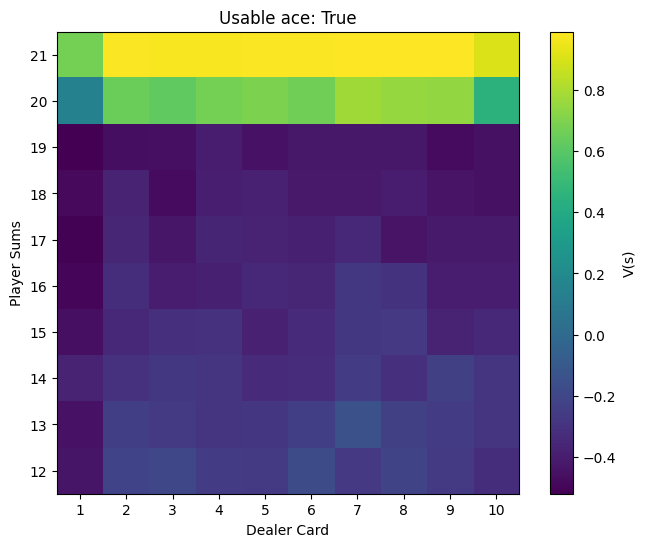

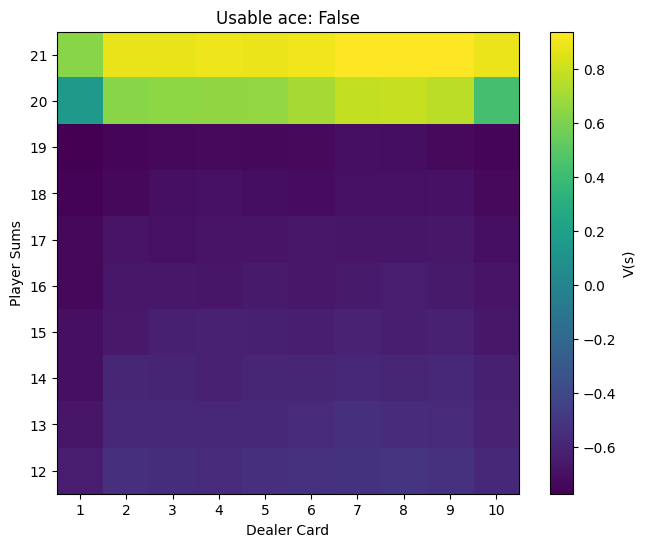

In [171]:
env = gym.make("Blackjack-v1", sab=True)

V, N = first_visit_mc_prediciton(env, 500000, 1)

env.close()

grid_usable_true = heat_map_grid(V, True)
grid_usable_false = heat_map_grid(V, False)

plot_heat_map(grid_usable_true, True)
plot_heat_map(grid_usable_false, False)

**Plots from my run**  
![alt text](image-2.png)  
![alt text](image-3.png)


## 1d

In [81]:
def epsilon_soft_policy(state, Q, epsilon):
    actions = [0, 1]

    if random.random() < epsilon:
        return random.choice(actions)

    stay = Q.get((state, 0), 0)
    hit = Q.get((state, 0), 0)

    if stay > hit:
        return 0
    
    elif hit > stay:
        return 1

    else:
        return random.choice(actions)

In [82]:
def single_episode_control(env, Q, epsilon):
    episode = []

    state, info = env.reset()
    complete = False

    while not complete:
        action = epsilon_soft_policy(state, Q, epsilon)

        next_state, reward, terminated, truncated, info, =  env.step(action)

        episode.append((state, action, reward))

        state = next_state

        if terminated is True or truncated is True:
            complete = True

    return episode

In [61]:
def mc_control(env, episodes, gama, epsilon):
    Q = {}
    N = {}

    for eps in range(episodes):
        episode = single_episode_control(env, Q, epsilon)

        states = []
        actions = []
        rewards = []

        for state, action, reward in episode:
            states.append(state)
            actions.append(action)
            rewards.append(reward)

            G = 0

        for t in reversed(range(len(episode))):
            state = states[t]
            action = actions[t]
            reward = rewards[t]

            G = reward + gama * G

            state_action = (state, action)

            prev_state_actions = []

            for i in range(t):
                prev_state_actions.append((states[i], actions[i]))

            if state_action in prev_state_actions:
                if state_action not in Q:
                    Q[state_action] = 0
                    N[state_action] = 0

                N[state_action] += 1
                Q[state_action] = Q[state_action] + (1 / N[state_action]) * (G - Q[state_action])

    return Q, N

In [88]:
def greedy_action(state, Q):
    stay = Q.get((state, 0), 0)
    hit = Q.get((state, 1), 0)

    if stay > hit:
        return 0
        
    elif hit > stay:
        return 1

    else:
        return np.random.choice([0, 1])

In [84]:
def policy_grid(Q, usable_ace):
    player_sums = np.arange(12, 22)
    dealer_cards = np.arange(1, 11)

    grid = np.zeros((len(player_sums), len(dealer_cards)))

    for i, player_sum in enumerate(player_sums):
        for j, dealer_card in enumerate(dealer_cards):
            state = (int(player_sum), int(dealer_card), usable_ace)
            grid[i, j] = greedy_action(state, Q)

    return grid

In [78]:
def plot_policy(grid, usable_ace):
    player_sums = np.arange(12, 22)
    dealer_cards = np.arange(1, 11)

    plt.figure(figsize=(8, 6))
    plt.imshow(grid, origin="lower")

    plt.xticks(ticks=np.arange(len(dealer_cards)), labels= dealer_cards)
    plt.yticks(ticks=np.arange(len(player_sums)), labels= player_sums)
    plt.title(f"Usable Ace: {usable_ace}")

    plt.xlabel("Dealer Cards")
    plt.ylabel("Pplayer Sum")

    for i in range(len(player_sums)):
        for j in range(len(dealer_cards)):
            if grid[i, j] == 1:
                label = "H"
            
            else:
                label = "S"

            plt.text(j, i, label)

    plt.show()

In [72]:
def compare(Q, usable_ace):
    player_sums = np.arange(12, 22)
    dealer_cards = np.arange(1, 11)

    differnce = []

    for player_sum in player_sums:
        for dealer_card in dealer_cards:
            state = (player_sum, dealer_card, usable_ace)

            greedy = greedy_action(state, Q)
            fixed = fixed_policy(state)

            if greedy != fixed:
                differnce.append((state, greedy, fixed))

    return differnce

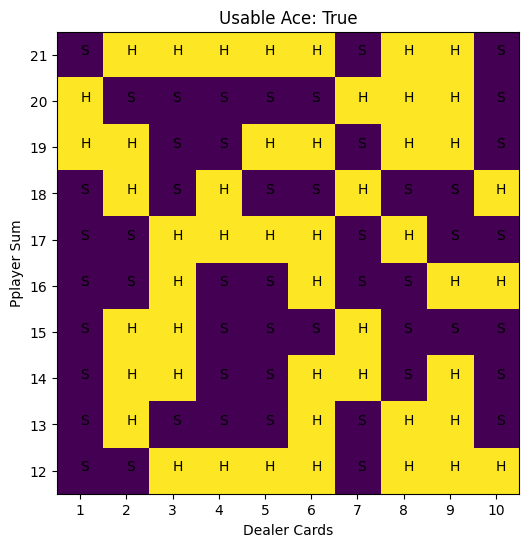

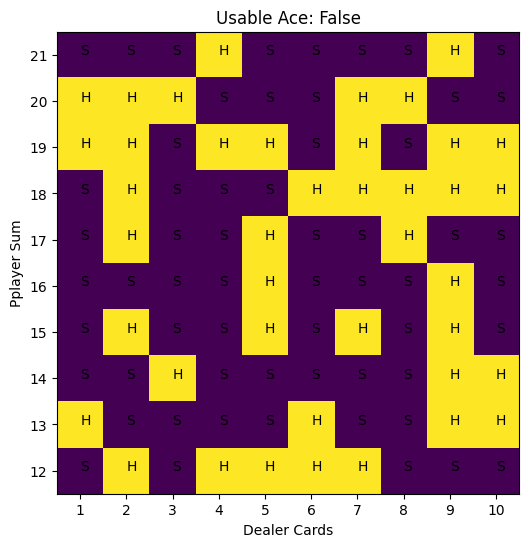

In [89]:
env = gym.make("Blackjack-v1", sab=True)

Q, N = mc_control(env, 500000, 1, 0.1)

env.close()

policy_grid_true = policy_grid(Q, True)
policy_grid_false = policy_grid(Q, False)

plot_policy(policy_grid_true, usable_ace=True)
plot_policy(policy_grid_false, usable_ace=False)

diff_true = compare(Q, True)
diff_false = compare(Q, False)

**Plots from my run**  
![alt text](image-4.png)  
![alt text](image-5.png)

**Comparing the learned policy to fixd policy**  
The fixed policy from part c was to stay if player sum is greater or equal to 20 and hit if less than 20. This means that the agent only stays when the player sums were 20 or 21. You can see this in the plot where the V(s) are only greater than 0 when the players sum is 20 or 21. This differes from the learned greedy policy which stays on player sums other than soly 20 or 21. You can see from the plot that the agent stays for all player sums. This leads to the agent staying at player sums that are not ideal. You can see that the agent stays at low player sums like 12, 13,14. Additonally,the greedy policy also hits when the player sums are high even 21 which is no ideal. 

## 1e



First Visit MC is unbaised because the total return for the episode only counts each state that is visited at most one time, where as Every Visit MC may count the same state multiple times during a single episode which can make it biased. 

If the exploration policy did not have a non zero chance for every action it would not effectively explere and could miss better actions. For example if you never hit in a state (12, 10, False) then you will end up not learning if hitting is the better action at this state.

A situation where you would prefer MC over TD is when the you have shorter episode such as in Blackjack. You would not prefer MC when you have a task that is continous because MC only updates after an episode is complete.

# Problem 2 Code

## 2c

In [112]:
def single_episode(start_state, t_left, t_right):
    episode = []
    state = start_state

    while state != t_left and state != t_right:
        action = random.choice(([-1, 1]))
        next_state = state + action

        if next_state == t_right:
            reward = 1

        else:
            reward = 0

        episode.append((state, reward, next_state))
        state = next_state

    return episode

In [128]:
def rms_error(V, true_vals):
    estimated_values = V[1:6]
    squared_errors = (estimated_values - true_vals) ** 2
    mean_squared_error = np.mean(squared_errors)

    return np.sqrt(mean_squared_error)

In [129]:
def td_prediction(state, t_left, t_right, true_vals, alpha, episodes):
    V = np.zeros(7)
    V[1:6] = 0.5
    rms_errors = []

    for ep in range(episodes):
        episode = single_episode(state, t_left, t_right)

        for state, reward, next_state in episode:
            td_target = reward + V[next_state]
            td_error = td_target - V[state]
            V[state] = V[state] + alpha * td_error

        rms_errors.append(rms_error(V, true_vals))

    return V, rms_errors



In [136]:
def mc_prediction(state, t_left, t_right, true_vals, alpha, gama, episodes):
    V = np.zeros(7)
    V[1:6] = 0.5
    rms_errors = []

    for i in range(episodes):
        episode = single_episode(state, t_left, t_right)
        
        states = []
        rewards = []

        for each in episode:
            states.append(each[0])
            rewards.append(each[1])

        G = 0

        for t in reversed(range(len(episode))):
            state = states[t]
            reward = rewards[t]
        
            G = reward + gama * G

            if state not in states[:t]:
                mc_error = G - V[state]
                V[state] = V[state] + alpha * mc_error
        
        rms_errors.append(rms_error(V, true_vals))

    return V, rms_errors

**2d**

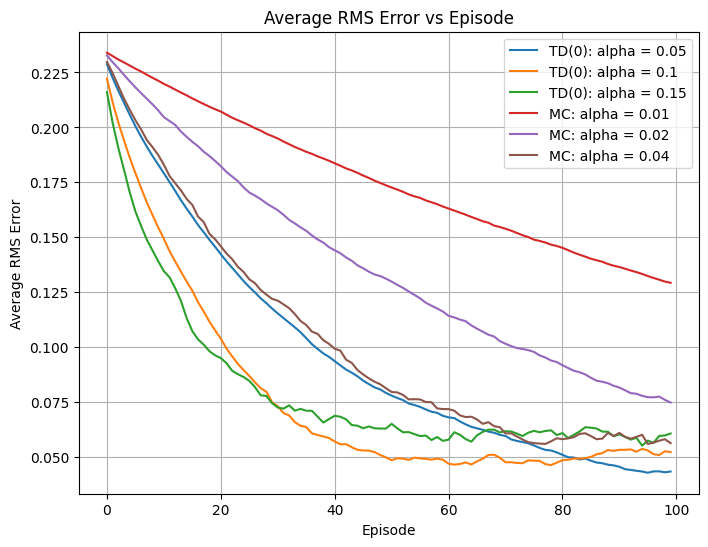

In [149]:
t_left = 0
t_right = 6
start_state = 3

true_vals = np.array([1/6, 2/6, 3/6, 4/6, 5/6])
td_alphas = [.05, .1, .15]
mc_alphas = [.01, .02, .04]

episodes = 100
runs = 50

td_results = {}
mc_results = {}

for alpha in td_alphas:
    all_td_errors = []

    for each in range(runs):
        td_V, td_errors = td_prediction(start_state, t_left, t_right, true_vals, alpha, episodes)
        all_td_errors.append(td_errors)
    
    td_results[alpha] = np.mean(np.array(all_td_errors), axis=0)


for alpha in mc_alphas:
    all_mc_errors = []

    for each in range(runs):
        mc_V, mc_errors = mc_prediction(start_state, t_left, t_right, true_vals, alpha, 1, episodes)
        all_mc_errors.append(mc_errors)
    
    mc_results[alpha] = np.mean(np.array(all_mc_errors), axis=0)

plt.figure(figsize=(8, 6))

for alpha in td_alphas:
    plt.plot(td_results[alpha], label=f"TD(0): alpha = {alpha}")

for alpha in mc_alphas:
    plt.plot(mc_results[alpha], label=f"MC: alpha = {alpha}")

plt.xlabel("Episode")
plt.ylabel("Average RMS Error")
plt.title("Average RMS Error vs Episode")

plt.legend()
plt.grid(True)
plt.show()

**Plot for my run**  
![alt text](image-6.png)